In [ ]:
# Import basic libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# For plotting
import matplotlib.pyplot as plt
from tqdm import tqdm

# For saving and loading
import pickle
%matplotlib inline

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')

plt.rcParams['figure.figsize'] = [5, 3]

# Assigning variables

In [ ]:
L = 20
s = 3
noise_sdmult = 0 #np.sqrt(0.1)
num_samps = 10000

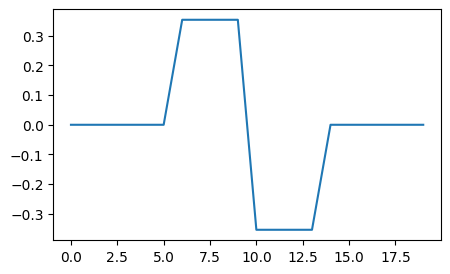

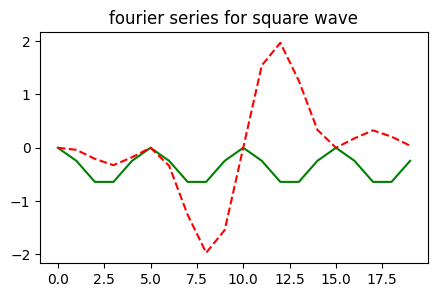

In [ ]:
denom = torch.sqrt(torch.tensor(2*torch.pi))

def mix_gauss(x, amp=torch.tensor([0.3, 1, -0.5]), mu=torch.tensor([1/8, 1/2, 3/4]), sd=torch.tensor([1/15, 1/10, 1/20])):
    # sd = sd * torch.ones(len(amp))
    to_ret = amp[:, None] * torch.exp(-0.5 * ((x[None, :] - mu[:, None])/sd[:, None])**2) / (denom * sd[:, None])

    return to_ret.sum(dim = 0)

signal = torch.cat((torch.zeros(6, device=device), torch.ones(4, device=device), -torch.ones(4, device=device), torch.zeros(6, device=device)), 0)
# signal = mix_gauss(torch.linspace(0, 1, steps=L)).to(device)  #, amp=torch.tensor([1.]), mu=torch.tensor([1/2]), sd=torch.tensor([1/3])
#signal = torch.rand(L)
signal *= 1/torch.norm(signal)
fft_signal = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(signal)))

# Plot signal in both real and fourier domain
plt.plot(signal.cpu())
plt.show()

plt.plot(fft_signal.cpu().real, 'g')
plt.plot(fft_signal.cpu().imag,'r--')
plt.title("fourier series for square wave")

plt.show()

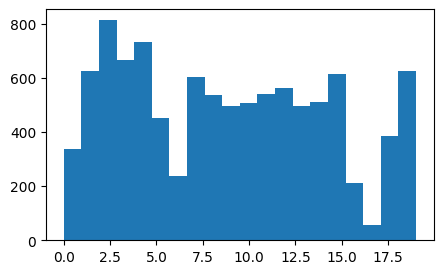

tensor(10)


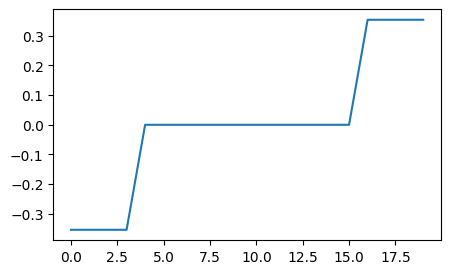

In [ ]:
multiplier = torch.linspace(-L/2, L/2 -1, steps = L, device=device) * -2*torch.pi*1j/L

# normal_dist = torch.distributions.normal.Normal(L/4, (L/11))
# rho = normal_dist.log_prob(torch.linspace(0, L-1, steps=L)).exp()
# normal_dist = torch.distributions.normal.Normal(3*L/4, (L/6))
# rho += normal_dist.log_prob(torch.linspace(0, L-1, steps=L)).exp()
rho = torch.rand(L)
rho = (rho/sum(rho)).to(device)
s_list = torch.multinomial(rho, num_samps, replacement=True).to(device)
#s_list = s_list.float() + torch.normal(mean=0.0, std=torch.ones(num_samps, device=device))
#s_list[0] = 0.0

plt.hist(s_list.cpu().numpy(), bins = int(L))
plt.show()

def circular_trans_fourier(v, s_list):
    rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()
    fft_v = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(v)))
    v_fftlist = rot_mat @ torch.diag(fft_v)
    v_translist = torch.fft.ifftshift(torch.fft.ifft(torch.fft.fftshift(v_fftlist))).real

    return v_translist

def circular_trans(v, s_list):
    v_translist = torch.empty((0, L), device=device)
    #v_fftlist = torch.empty((0, L))
    for s in s_list:
        trans_signal = torch.cat((v[-s:], v[:-s])) #+ torch.normal(mean=0.0, std=torch.ones(L)*signal.max()*noise_sdmult)
        v_translist = torch.vstack((v_translist, trans_signal))
        #v_fftlist = torch.vstack((v_fftlist, torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(trans_signal)))))

    return v_translist

noise_rvs = torch.normal(mean=0.0, std=torch.ones((num_samps, L), device=device)*noise_sdmult)
noise_fft = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(noise_rvs)))

v_ori = circular_trans_fourier(signal, s_list).to(device)
v_fftori = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(v_ori)))

v_translist = v_ori + noise_rvs
v_fftlist = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(v_translist)))

print(s_list[0])
plt.plot(v_translist[0].cpu())
plt.show()

In [ ]:
# Sanity Check

m1_ground = torch.mean(v_fftori, 0);
m1_trans = torch.mean(v_fftlist, 0);

m2_ground = (v_fftori.T @ v_fftori)/num_samps
dftmtx = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(torch.eye(L, device=device))))
m2_trans = dftmtx.T @ ((v_translist.T @ v_translist).to(torch.cfloat)/num_samps - (noise_sdmult)**2 *torch.eye(L, device=device)) @ dftmtx

noise_m2 = (noise_fft.T @ noise_fft)/num_samps

print(torch.norm(m1_trans - m1_ground)/torch.norm(m1_ground))
print(torch.norm(m1_ground))

print(torch.norm(m2_trans - m2_ground)/torch.norm(m2_ground))
print(torch.norm(m2_ground))

print(torch.norm(noise_fft))
print(torch.norm(noise_m2))

tensor(0.)
tensor(0.4958)
tensor(4.1163e-07)
tensor(7.7492)
tensor(0.)
tensor(0.)


In [ ]:
def circ(tensor, dim):
    """get a circulant version of the tensor along the {dim} dimension.

    The additional axis is appended as the last dimension.
    E.g. tensor=[0,1,2], dim=0 --> [[0,1,2],[2,0,1],[1,2,0]]"""
    S = tensor.shape[dim]
    tmp = torch.cat([tensor.flip((dim,)), torch.narrow(tensor.flip((dim,)), dim=dim, start=0, length=S-1)], dim=dim)
    return tmp.unfold(dim, S, 1).flip((-1,)).T


v_ori2 = circular_trans_fourier(signal, s_list).to(device)
m1_ground2 = torch.mean(v_ori2, 0);
m2_ground2 = (v_ori2.T @ v_ori2)/num_samps


# print(circ(torch.tensor([1,2,3]), 0))
print(torch.norm((circ(signal, 0) @ rho[:, None]).flatten() - m1_ground2)/torch.norm(m1_ground2))
print(torch.norm(m2_ground2 - circ(signal, 0) @ torch.diag(rho) @ circ(signal, 0).T)/torch.norm(m2_ground2))
s_list = torch.multinomial(rho, num_samps, replacement=True).to(device)

print('Clean data:')
print()

print(f'Norm of first moment of estimator: {torch.norm(m1_ground)}')
print(f'Relative error in first moments of 2 different estimators: {torch.norm(m1_ground2 - m1_ground)/torch.norm(m1_ground)}')
print(f'Relative error in first moments of estimator and theory: {torch.norm((circ(signal, 0) @ rho[:, None]).flatten() - m1_ground)/torch.norm(m1_ground)}')

print()

print(f'Norm of second moment of estimator: {torch.norm(m2_ground)}')
print(f'Relative error in second moments of 2 different estimators: {torch.norm(m2_ground2 - m2_ground)/torch.norm(m2_ground)}')
print(f'Relative error in second moments of estimator and theory: {torch.norm(circ(signal, 0) @ torch.diag(rho) @ circ(signal, 0).T - m2_ground)/torch.norm(m2_ground)}')

tensor(0.0739)
tensor(0.0208)
Clean data:

Norm of first moment of estimator: 0.4958083927631378
Relative error in first moments of 2 different estimators: 0.9611315727233887
Relative error in first moments of estimator and theory: 0.9660965800285339

Norm of second moment of estimator: 7.7491655349731445
Relative error in second moments of 2 different estimators: 1.0056381225585938
Relative error in second moments of estimator and theory: 1.0056792497634888


In [ ]:
print('Noisy data with sigma = 1.0 :')
print()

print(f'Norm of first moment of estimator: {torch.norm(m1_trans)}')
print(f'Relative error in first moments of estimator and grndtruth: {torch.norm(m1_trans - m1_ground)/torch.norm(m1_ground)}')
#print(f'Relative error in first moments of estimator and theory: {torch.norm(m1_trans - (circ(signal, 0) @ rho[:, None]).flatten())/torch.norm((circ(signal, 0) @ rho[:, None]).flatten())}')

print()

print(f'Norm of second moment ground truth: {torch.norm(m2_trans)}')
print(f'Relative error in second moments of 2 different estimators: {torch.norm(m2_trans - m2_ground)/torch.norm(m2_ground)}')
#print(f'Relative error in second moments of estimator and theory: {torch.norm(m2_trans - circ(signal, 0) @ torch.diag(rho) @ circ(signal, 0).T)/torch.norm(circ(signal, 0) @ torch.diag(rho) @ circ(signal, 0).T)}')

Noisy data with sigma = 1.0 :

Norm of first moment of estimator: 0.4958083927631378
Relative error in first moments of estimator and grndtruth: 0.0

Norm of second moment ground truth: 7.749166011810303
Relative error in second moments of 2 different estimators: 4.116311060897715e-07


In [ ]:
m1 = torch.mean(v_fftlist, 0)
m2 = (v_fftlist.T @ v_fftlist)/num_samps - (noise_sdmult*signal.max())**2 *torch.eye(L, device=device)

dftmtx = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(torch.eye(L, device=device))))
m2 = dftmtx.T @ ((v_translist.T @ v_translist).to(torch.cfloat)/num_samps - (noise_sdmult)**2 *torch.eye(L, device=device)) @ dftmtx
m1aliter = dftmtx @ torch.mean(v_translist.to(torch.cfloat), 0)
# m1 = torch.mean(v_fftori, 0)
# m2 = (v_fftori.T @ v_fftori)/num_samps

print(m1.shape)
print(m2.shape)

print(torch.norm(m1))
print(torch.norm(m2))

print(torch.norm(m1 - m1aliter))

torch.Size([20])
torch.Size([20, 20])
tensor(0.4958)
tensor(7.7492)
tensor(9.9197e-08)


In [ ]:
m1real = torch.mean(v_translist, 0)
m2real = ((v_translist.T @ v_translist)/num_samps - (noise_sdmult)**2 *torch.eye(L, device=device))

print(m1.shape)
print(m2.shape)

torch.Size([20])
torch.Size([20, 20])


# Training/Testing 100 moment dataset (different signals)

torch.Size([20])
torch.Size([20])
torch.Size([20, 20])


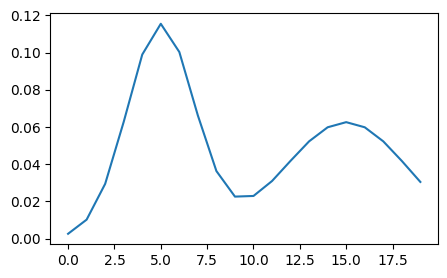

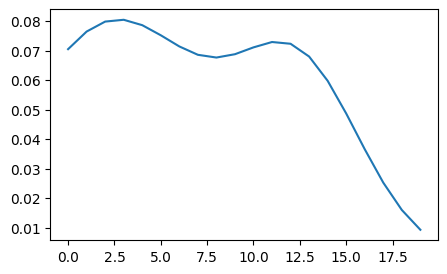

In [ ]:
def diff_min(mat, rho = 200, dim = -1):
    return -(1/rho) * torch.logsumexp(-rho * mat, dim)


def create_moments(rho = rho, sig = signal):
    m1real = (circ(sig, 0) @ rho[:, None]).flatten()
    m2real = circ(sig, 0) @ torch.diag(rho) @ circ(sig, 0).T

    return m1real, m2real


def create_data(mu_rho = torch.tensor([1/4, 3/4]), sd_rho = torch.tensor([1/11, 1/6]), amp_sig = torch.tensor([1, 1/2]), mu_sig = torch.tensor([1/8, 5/8]), sd_sig = torch.tensor([1/4, 1/6])):
    rho = 0
    for j in range(len(mu_rho)):
        normal_dist = torch.distributions.normal.Normal(L*mu_rho[j], (L*sd_rho[j]))
        rho += normal_dist.log_prob(torch.linspace(0, L-1, steps=L)).exp()
    rho = (rho/sum(rho)).to(device)

    sig = 0
    for j in range(len(mu_sig)):
        normal_dist = torch.distributions.normal.Normal(L*mu_sig[j], (L*sd_sig[j]))
        sig += amp_sig[j] * normal_dist.log_prob(torch.linspace(0, L-1, steps=L)).exp().to(device)

    m1real, m2real = create_moments(rho = rho, sig = sig)

    return m1real, m2real, rho, sig


def best_registration(original, recon, search_space_mult = 100):
    rots = torch.linspace(0, L, steps=search_space_mult*L, device=device)
    rot_reconlist = circular_trans_fourier(recon, rots)

    errors = torch.norm(rot_reconlist - original, dim=1)
    min_idx = torch.argmin(errors)

    best_s = rots[min_idx]
    best_error = errors[min_idx]/torch.norm(original)
    best_recon = rot_reconlist[min_idx]

    return best_s, best_error, best_recon


def moment_registration(rho, sig, m1, m2, search_space_mult = 100):
    rots = torch.linspace(0, L, steps=search_space_mult*L, device=device)
    sig_rotlist = circular_trans_fourier(sig, rots)

    s_quad = torch.arange(L, device=device)[:, None].type(torch.complex64)
    loss_lst = np.array([])

    for sig_rot in sig_rotlist:
        recon_fft = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(sig_rot)))

        rot_mat = (s_quad @ multiplier[None, :]).exp()
        Rvlist = rot_mat @ torch.diag(recon_fft)

        m1hat = torch.sum((torch.diag(rho) @ Rvlist), 0)
        m2hat = (Rvlist.T @ torch.diag(rho) @ Rvlist)
        loss = torch.norm(m1 - m1hat)/torch.norm(m1) + torch.norm(m2 - m2hat)/torch.norm(m2)

        loss_lst = np.append(loss_lst, loss.to('cpu').data.numpy())

    min_idx = np.argmin(loss_lst)
    max_idx = np.argmax(loss_lst)
    # print([loss_lst[max_idx], loss_lst[min_idx], loss_lst[max_idx]/loss_lst[min_idx]])

    return rots[min_idx], sig_rotlist[min_idx]


m1real, m2real, rho, sig = create_data()

print(rho.shape)
print(m1real.shape)
print(m2real.shape)

plt.plot(rho.cpu().numpy())
plt.show()
plt.plot(sig.cpu().numpy())
plt.show()

In [ ]:
m1_stack = torch.empty((0,L), device=device)
m2_stack = torch.empty((0,L,L), device=device)
rho_stack = torch.empty((0,L), device=device)
sig_stack = torch.empty((0,L), device=device)

print(m1_stack.shape)
print(m2_stack.shape)

print(m1_stack)

torch.Size([0, 20])
torch.Size([0, 20, 20])
tensor([], size=(0, 20))


In [ ]:
num_unique = 200

rhos = []
sigs = []

for i in range(num_unique):
    # Parameters of family of distribution
    mu_rho = torch.rand(2)
    sd_rho = torch.rand(2) * (1/10 - 1/20) + 1/20  # (1/10 - 1/20) + 1/20

    # Parameters of family of signal
    mu_sig = torch.rand(2) #torch.tensor([1, 2, 3, 4])/5 #
    sd_sig = torch.rand(2) * (1/10 - 1/20) + 1/20  #/20 #
    amp_sig = torch.ones(2) #torch.rand(10)
    amp_sig = amp_sig/amp_sig.sum()

    # Data creation
    _, _, rho, sig = create_data(mu_rho=mu_rho, sd_rho=sd_rho, amp_sig=amp_sig, mu_sig=mu_sig, sd_sig=sd_sig)

    rhos.append(rho)
    sigs.append(sig)


rhos = torch.stack(rhos).to(device)
sigs = torch.stack(sigs).to(device)

In [ ]:
m1_list = []
m2_list = []
rho_list = []
sig_list = []

for i in range(num_unique):
    for j in range(num_unique):
        m1real, m2real = create_moments(rhos[i], sigs[j])

        m1_list.append(m1real)
        m2_list.append(m2real)
        rho_list.append(rhos[i])
        sig_list.append(sigs[j])

    if ((i + 1) % 100 == 0):
        print(f'Finished {i}th run')


print(len(m1_list))
print(len(m2_list))
print(len(rho_list))
print(len(sig_list))

Finished 99th run
Finished 199th run
40000
40000
40000
40000


torch.Size([40000, 20])
torch.Size([40000, 20, 20])
torch.Size([40000, 20])
torch.Size([40000, 20])


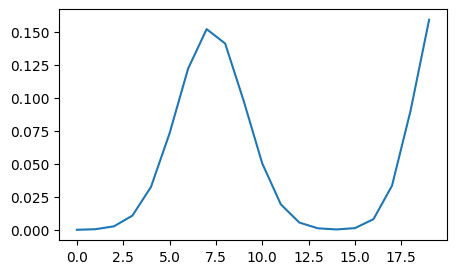

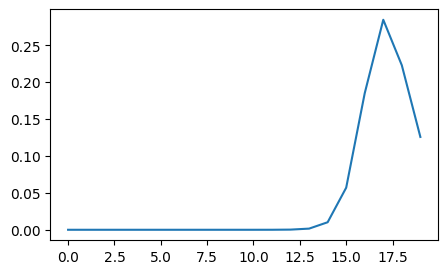

In [ ]:
m1_stack = torch.cat((m1_stack, torch.stack(m1_list).to(device)), dim=0)
m2_stack = torch.cat((m2_stack, torch.stack(m2_list).to(device)), dim=0)
rho_stack = torch.cat((rho_stack, torch.stack(rho_list).to(device)), dim=0)
sig_stack = torch.cat((sig_stack, torch.stack(sig_list).to(device)), dim=0)

print(m1_stack.shape)
print(m2_stack.shape)
print(rho_stack.shape)
print(sig_stack.shape)

idx = 600

plt.plot(rho_stack[idx].cpu().numpy())
plt.show()
plt.plot(sig_stack[idx].cpu().numpy())
plt.show()

# NN define

In [ ]:
class rhonet(nn.Module):  # filters=32, kernel=15
    def __init__(self, input_dim=L, n_conv_filters=32, n_interm_channel=3, kernel_size=15, hidden_dim=256, output_dim=1, parm_limit=0.25, act_parm=0.02,):
        super(rhonet, self).__init__()

        # Activation function setting
        if (act_parm > 0) & (act_parm < 1):
            act_func = nn.LeakyReLU(act_parm)
        else:
            act_func = nn.Tanh()

        self.fc_inpdim = n_interm_channel * L
        self.pad = int((kernel_size - 1)/2)

        # CNN for m1
        self.cnn_m1 = nn.Sequential(
            nn.Conv1d(1, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_interm_channel, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            # nn.MaxPool1d(2),
        )

        # CNN for m2
        self.cnn_m2 = nn.Sequential(
            nn.Conv1d(input_dim, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_interm_channel, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            # nn.MaxPool1d(2),
        )

        # CNN for their combination
        self.cnn_combine =  nn.Sequential(
            nn.Conv1d(2*n_interm_channel, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_conv_filters, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            nn.Conv1d(n_conv_filters, n_interm_channel, kernel_size=kernel_size, padding=self.pad, padding_mode='circular'),
            act_func,
            # nn.MaxPool1d(2),
        )

        # Fully connected layer in the end
        self.fc =  nn.Sequential(
            nn.Linear(self.fc_inpdim, hidden_dim),
            act_func,
            nn.Linear(hidden_dim, hidden_dim),
            act_func,
            nn.Linear(hidden_dim, hidden_dim),
            act_func,
            nn.Linear(hidden_dim, input_dim),
        )

        # Initialization of parameters
        def init_weights(m):
            if type(m) == nn.Linear:
                nn.init.uniform_(m.weight, -parm_limit, parm_limit)
                nn.init.uniform_(m.bias, -parm_limit, parm_limit)

        self.cnn_m1.apply(init_weights)
        self.cnn_m2.apply(init_weights)
        self.cnn_combine.apply(init_weights)
        self.fc.apply(init_weights)

    def forward(self, first_moment, second_moment):
        out_m1 = self.cnn_m1(first_moment[:, None, :])
        # print(out_m1.shape)
        out_m2 = self.cnn_m2(second_moment)
        # print(out_m2.shape)
        out_combine = self.cnn_combine(torch.cat((out_m1, out_m2), dim=1))
        # print(out_combine.shape)
        out = self.fc(out_combine.reshape(-1, self.fc_inpdim))
        return F.softmax(out, dim=1)

model_rho = rhonet(act_parm=0.02).to(device)
print(model_rho(m1_stack[:2], m2_stack[:2]))

tensor([[0.0583, 0.0426, 0.0460, 0.0286, 0.0556, 0.1020, 0.0811, 0.0233, 0.0613,
         0.0332, 0.0340, 0.0774, 0.0095, 0.0902, 0.0146, 0.0432, 0.1078, 0.0238,
         0.0525, 0.0153],
        [0.0583, 0.0426, 0.0460, 0.0285, 0.0556, 0.1020, 0.0811, 0.0233, 0.0613,
         0.0332, 0.0340, 0.0774, 0.0095, 0.0902, 0.0146, 0.0432, 0.1078, 0.0238,
         0.0525, 0.0153]], grad_fn=<SoftmaxBackward0>)


In [ ]:
class signet(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=256, output_dim=1, act_parm=0.02):
        super(signet, self).__init__()

        if (act_parm > 0) & (act_parm < 1):
            act_func = nn.LeakyReLU(act_parm)
        else:
            act_func = nn.Tanh()

        self.r = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )

        self.theta = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(act_parm),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.r(x) + self.theta(x)*1j # self.r(x) * torch.exp(self.theta(x)*torch.pi*1j) #

model_sig = signet(act_parm=-1).to(device)
input_sig = torch.linspace(0, 1/2 - 1/L, steps = int(L/2), device=device)[:, None] #torch.linspace(0, L-1, steps=L, device=device)[:, None]

# Learn rhos

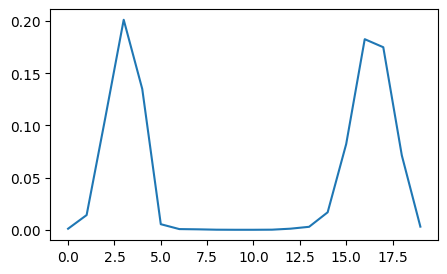

In [ ]:
model_rho = rhonet(act_parm=0.02).to(device)

recon_rho = model_rho(m1_stack[:1], m2_stack[:1])
# print(recon_rho[0].sum())
plt.plot(recon_rho[0].data.cpu().numpy())
plt.show()

In [ ]:
# Train model
num_test = 50**2 #num_unique**2
num_train = len(m2_stack) - num_test

max_iter = 25000
batch_size = 512
show_iter = 250

loss_hist = np.array([])
s_list = torch.linspace(0, L-1, steps = 10*L, device=device)
rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()

optimizer_rho = torch.optim.Adam(model_rho.parameters(), lr=3e-4, weight_decay=1e-10)

for it in tqdm(range(max_iter)):
    model_rho.train()

    if ((it + 1) % show_iter == 0):
        print("Loss {}".format(loss.item()))

    indices = torch.randint(num_train, (batch_size,))
    # loss = torch.norm(model_rho(m1_stack[indices], m2_stack[indices]) - rho_stack[indices])

    fft_rho_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(rho_stack[indices])))
    trans_rho_stack = rot_mat @ torch.diag_embed(fft_rho_stack)

    recon_rho = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_rho(m1_stack[indices], m2_stack[indices]))))
    loss = diff_min(torch.norm(recon_rho[:, None, :] - trans_rho_stack, dim=2)).sum()/batch_size

    optimizer_rho.zero_grad()
    loss.backward()
    optimizer_rho.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

plt.figure(figsize=(5, 5))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

  1%|          | 249/25000 [01:33<2:25:35,  2.83it/s]

Loss 0.2554038166999817


  2%|▏         | 499/25000 [03:08<2:20:46,  2.90it/s]

Loss 0.23346656560897827


  3%|▎         | 749/25000 [04:43<2:59:30,  2.25it/s]

...

Loss 0.23337967693805695


  7%|▋         | 1749/25000 [11:00<2:14:35,  2.88it/s]

Loss 0.2438088357448578


  7%|▋         | 1781/25000 [11:13<2:26:15,  2.65it/s]


KeyboardInterrupt: 

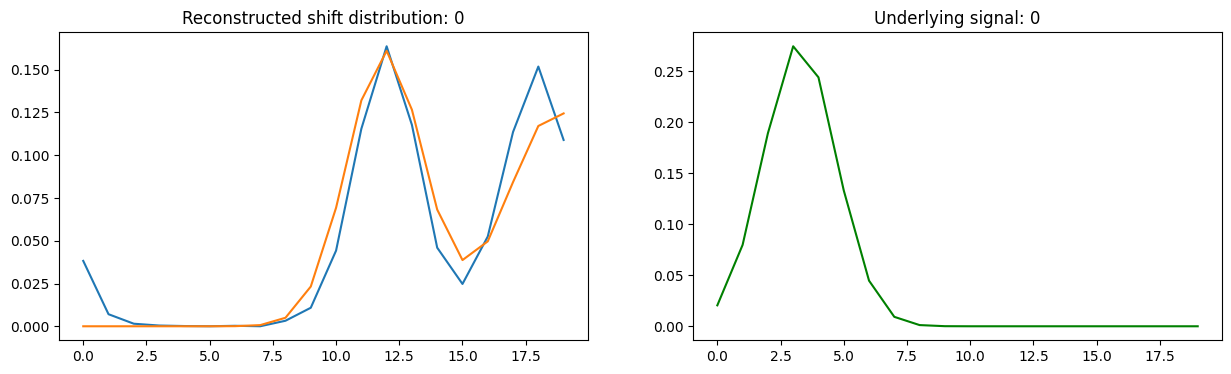

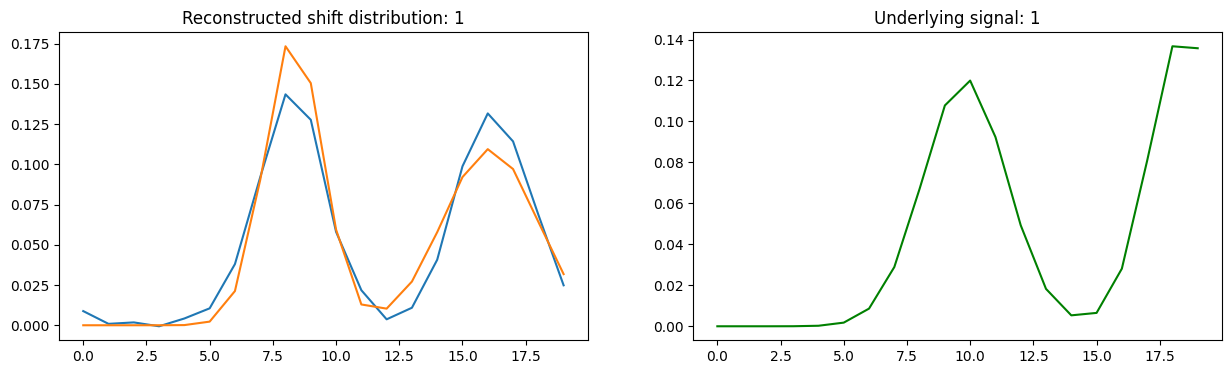

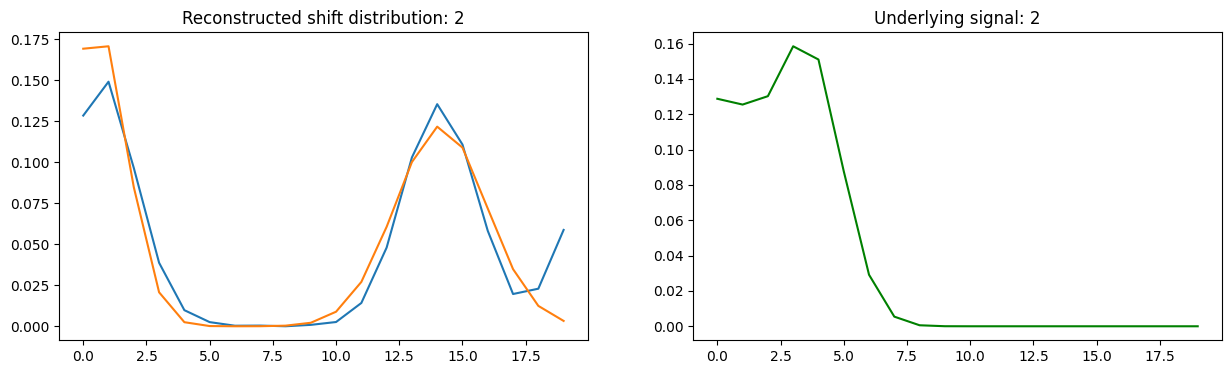

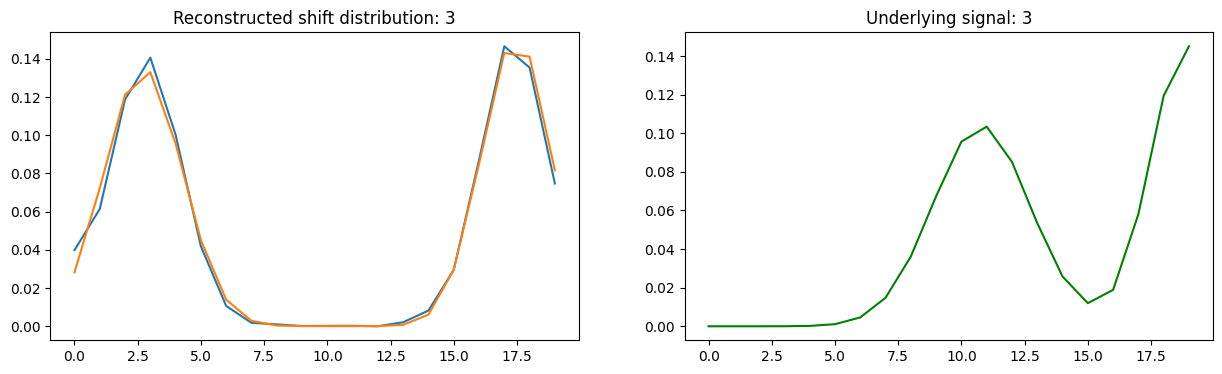

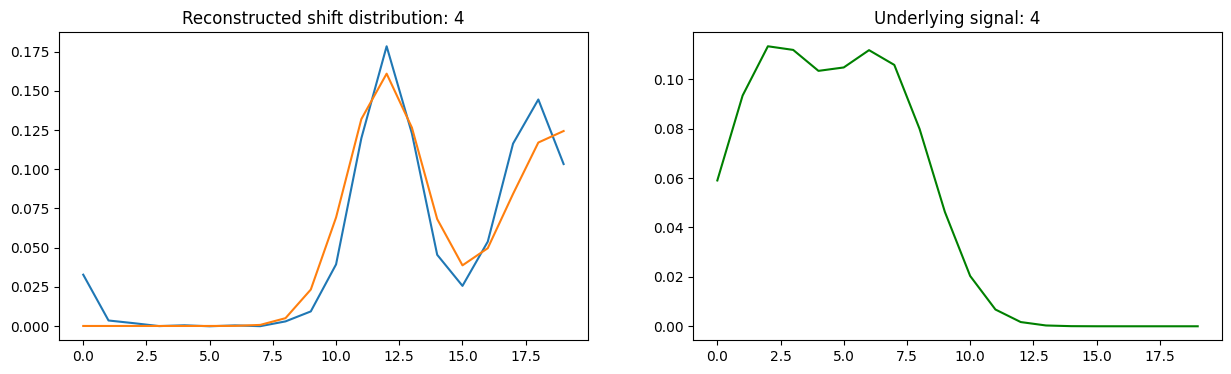

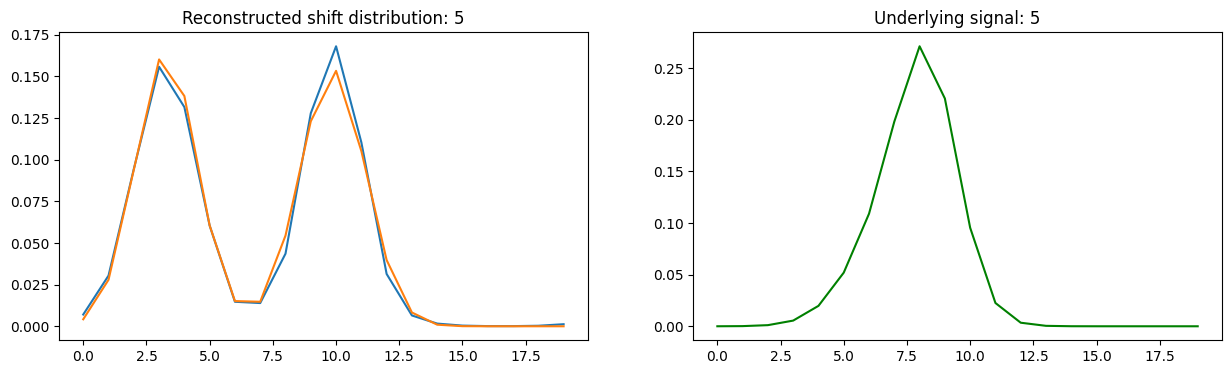

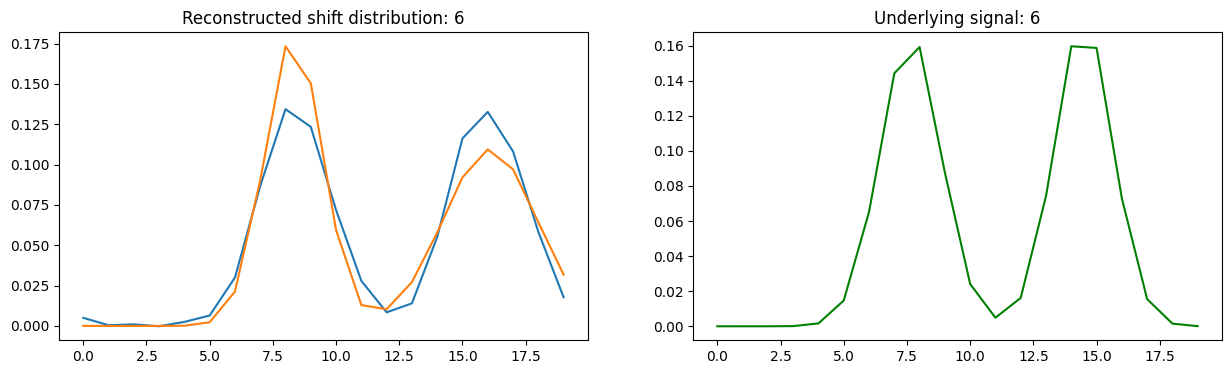

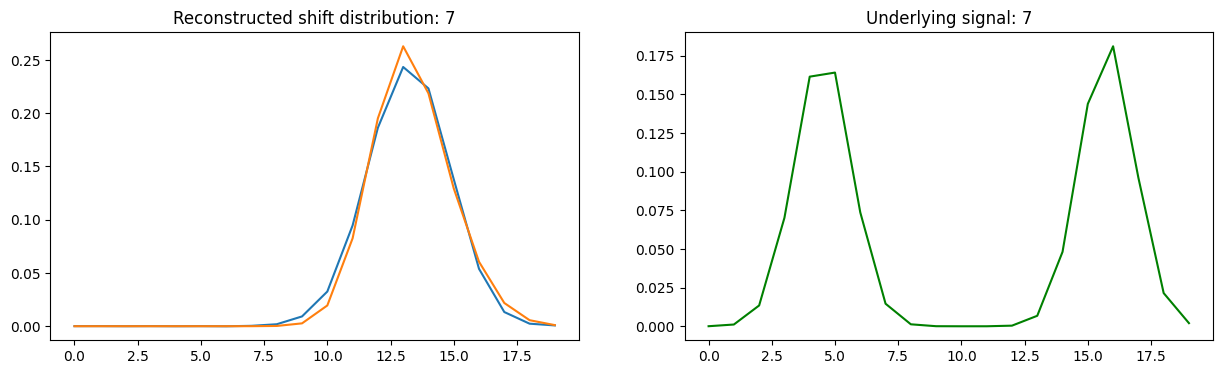

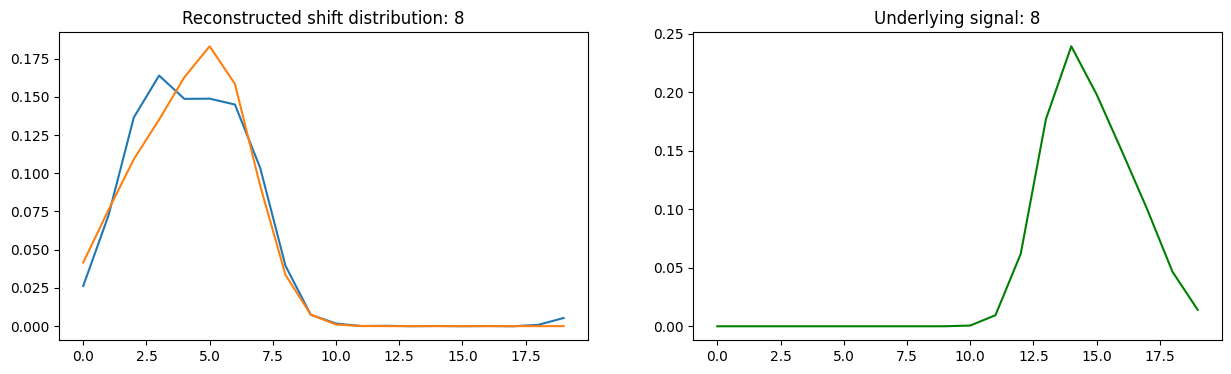

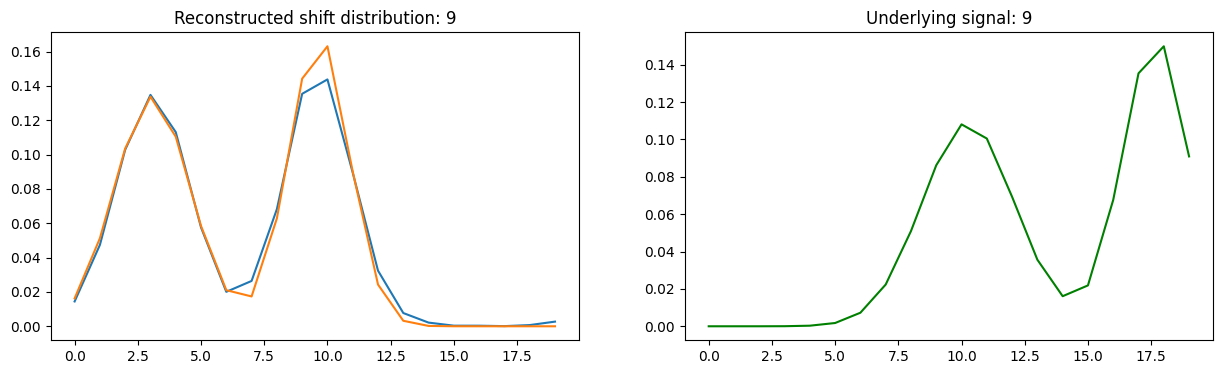

tensor(0.2381, grad_fn=<DivBackward0>)


In [ ]:
# Performance on training set
idxs = torch.randint(num_train, (10,))
i = 0
recon_rho = model_rho(m1_stack[idxs], m2_stack[idxs])

for idx in idxs:
    fig = plt.gcf()
    fig.set_size_inches(15, 4)

    best_s, best_error, best_recon = best_registration(rho_stack[idx], recon_rho[i])

    plt.subplot(1, 2, 1)
    plt.plot(best_recon.data.cpu().numpy())
    plt.plot(rho_stack[idx].cpu().numpy())
    plt.title(f'Reconstructed shift distribution: {i}')

    plt.subplot(1, 2, 2)
    plt.plot(sig_stack[idx].cpu().numpy(), color='green')
    plt.title(f'Underlying signal: {i}')

    plt.show()
    i += 1

# print(idxs)
indices = torch.randint(num_train, (5000,)) # 1750000 + torch.randint(250000, (1000,)) #

fft_rho_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(rho_stack[indices])))
trans_rho_stack = rot_mat @ torch.diag_embed(fft_rho_stack)

recon_rho = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_rho(m1_stack[indices], m2_stack[indices]))))
loss = diff_min(torch.norm(recon_rho[:, None, :] - trans_rho_stack, dim=2)).sum()/5000

print(loss)

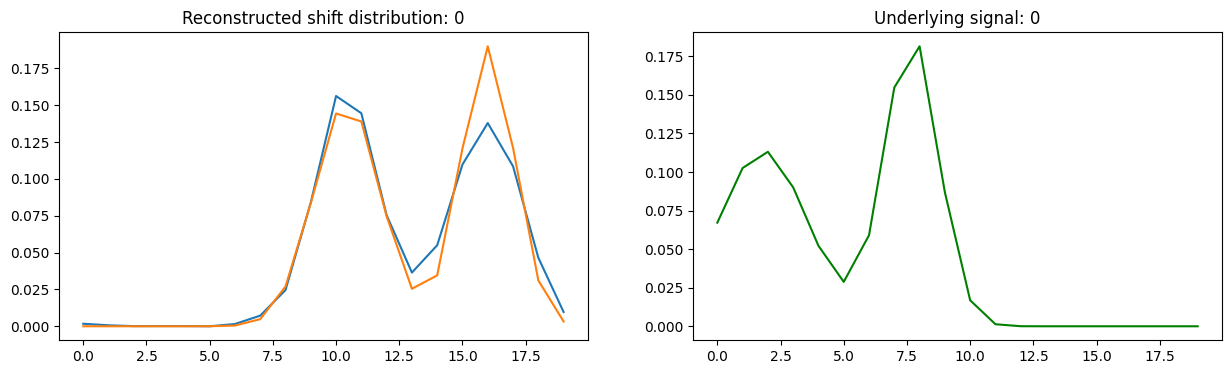

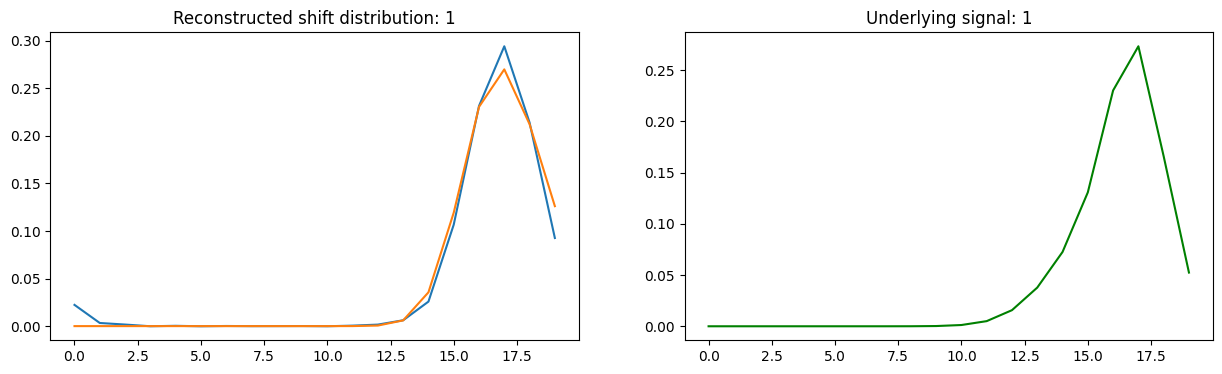

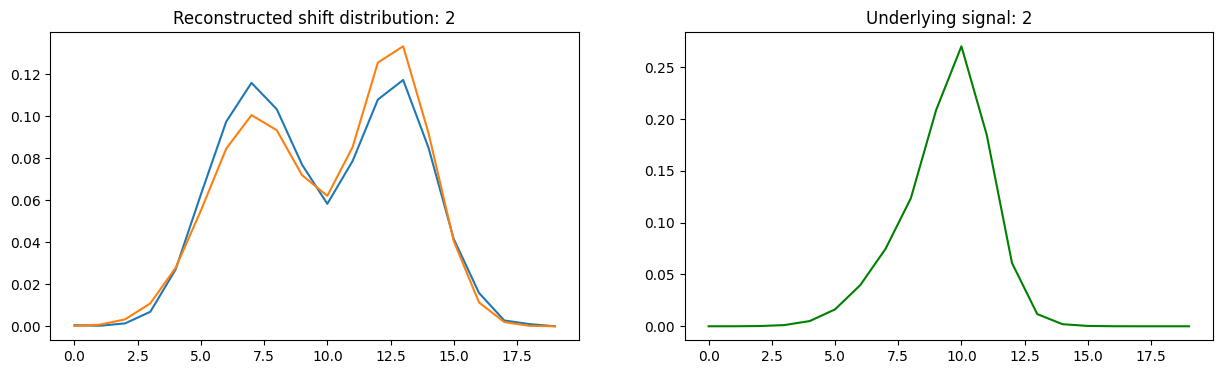

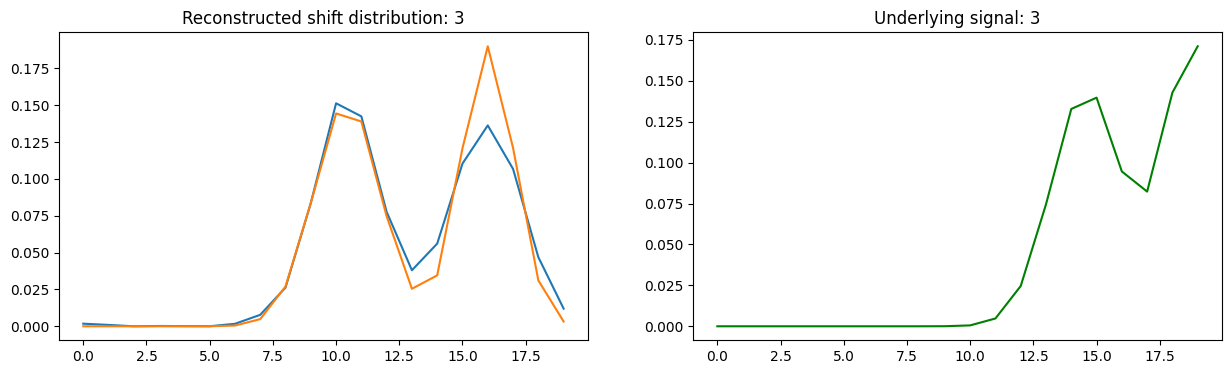

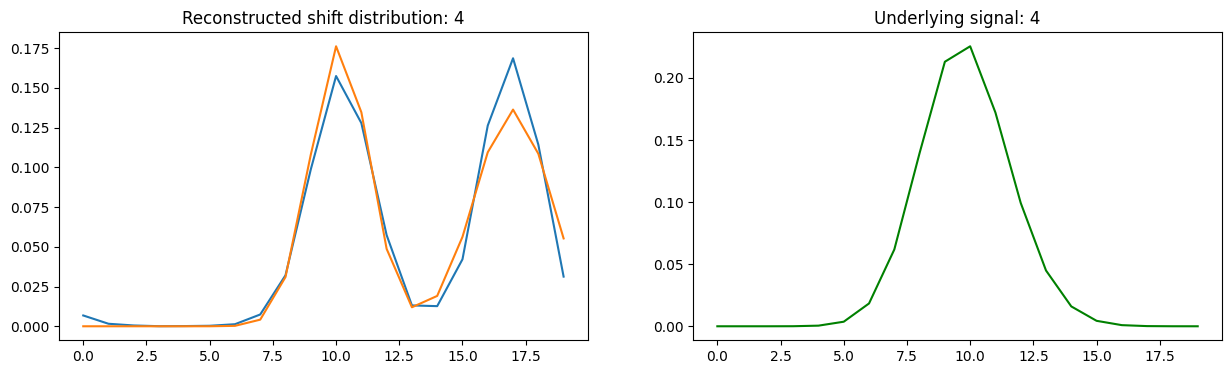

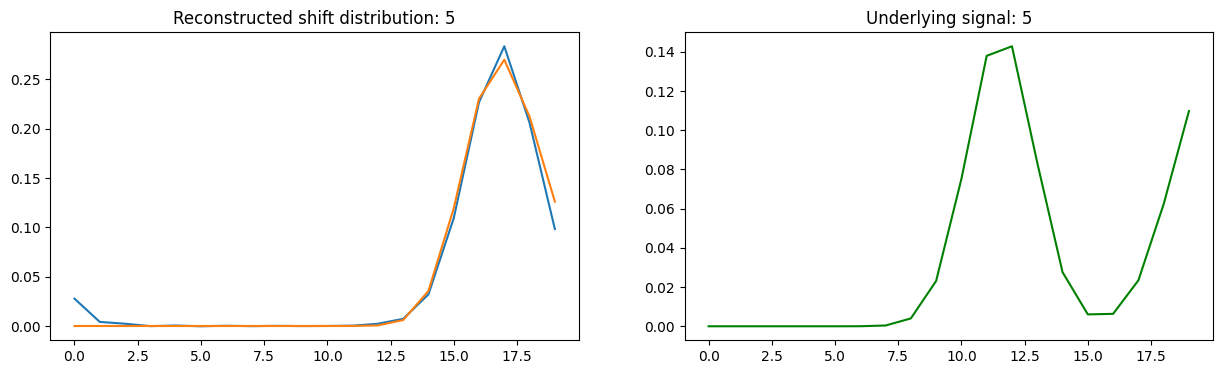

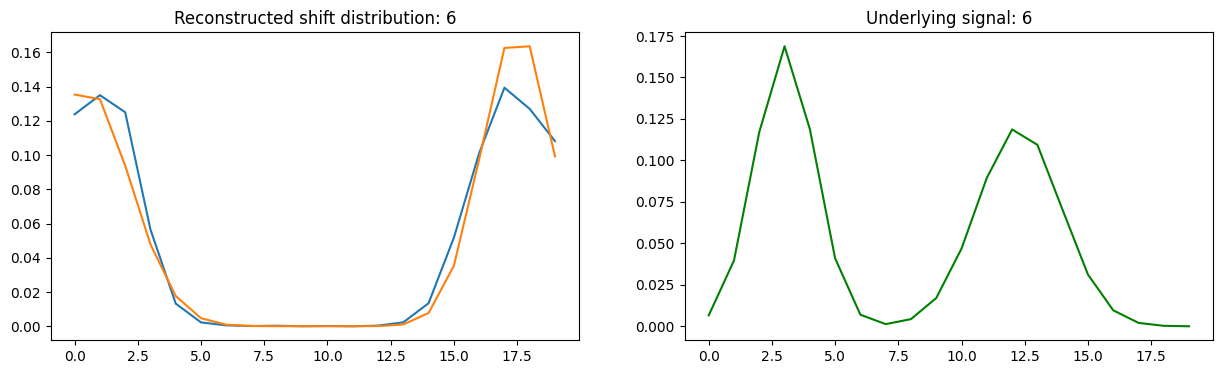

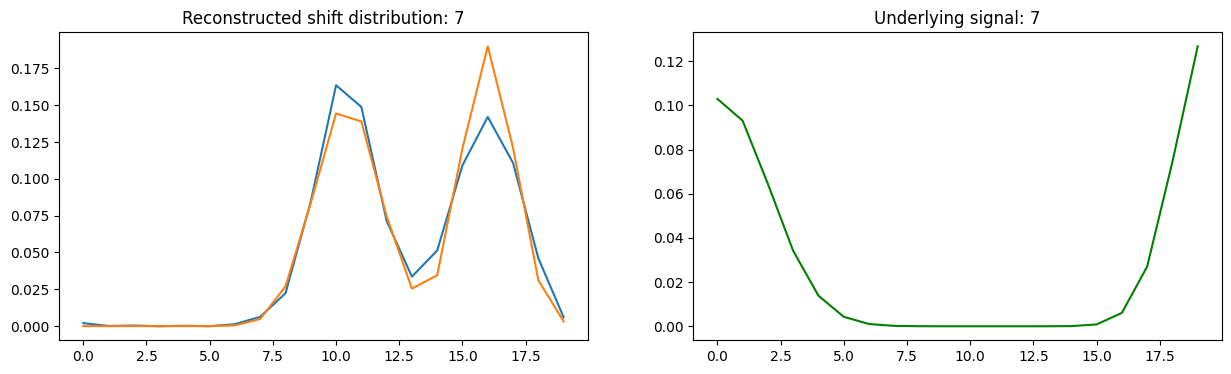

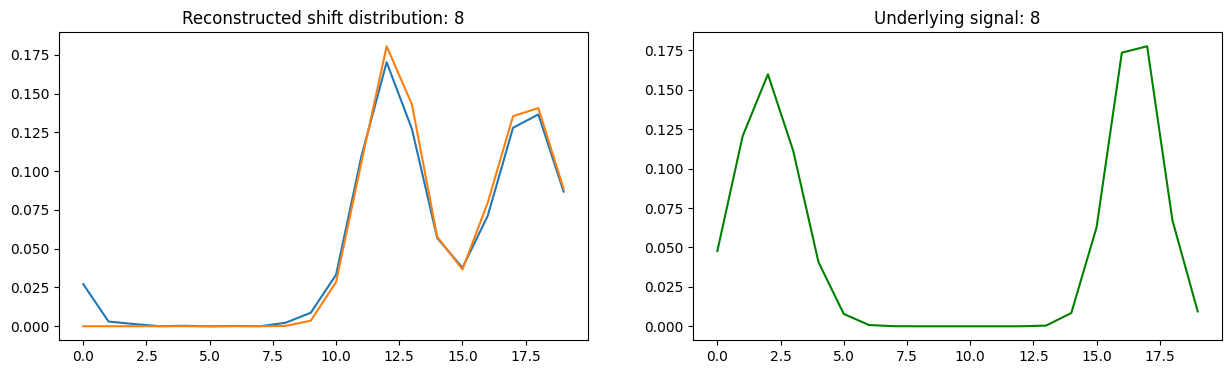

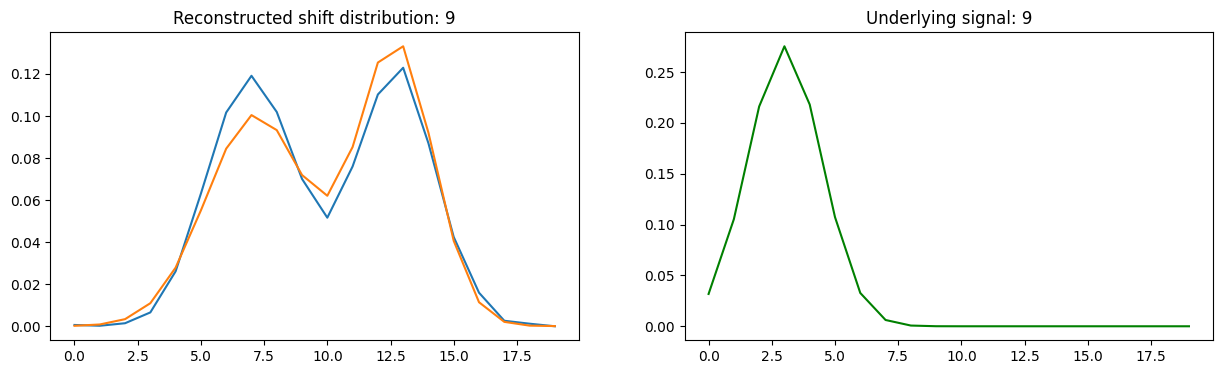

tensor(0.2491, grad_fn=<DivBackward0>)


In [ ]:
# num_train = len(m2_stack) - num_unique**2
# num_test = num_unique**2
s_list = torch.linspace(0, L-1, steps = 10*L, device=device)
rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()

# Performance on test set
idxs = num_train + torch.randint(num_test, (10,))
i = 0
recon_rho = model_rho(m1_stack[idxs], m2_stack[idxs])

for idx in idxs:
    fig = plt.gcf()
    fig.set_size_inches(15, 4)

    best_s, best_error, best_recon = best_registration(rho_stack[idx], recon_rho[i])

    plt.subplot(1, 2, 1)
    plt.plot(best_recon.data.cpu().numpy())
    plt.plot(rho_stack[idx].cpu().numpy())
    plt.title(f'Reconstructed shift distribution: {i}')

    plt.subplot(1, 2, 2)
    plt.plot(sig_stack[idx].cpu().numpy(), color='green')
    plt.title(f'Underlying signal: {i}')

    plt.show()
    i += 1

indices = num_train + torch.randint(num_test, (num_test,))

fft_rho_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(rho_stack[indices])))
trans_rho_stack = rot_mat @ torch.diag_embed(fft_rho_stack)

recon_rho = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_rho(m1_stack[indices], m2_stack[indices]))))
loss = diff_min(torch.norm(recon_rho[:, None, :] - trans_rho_stack, dim=2)).sum()/num_test

print(loss)

# Learn Sig

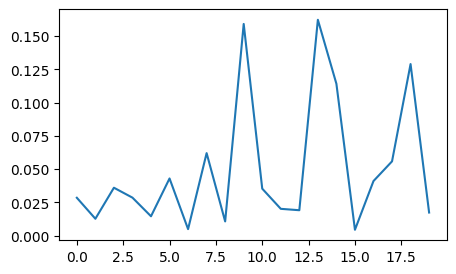

In [ ]:
model_v = rhonet(act_parm=0.02).to(device)

recon_v = model_v(m1_stack[:1], m2_stack[:1])
# print(recon_rho[0].sum())
plt.plot(recon_v[0].data.cpu().numpy())
plt.show()

In [ ]:
# Train model
num_test = 50**2
num_train = len(m2_stack) - num_test

max_iter = 25000
batch_size = 512
show_iter = 250

loss_hist = np.array([])
s_list = torch.linspace(0, L-1, steps = 10*L, device=device)
rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()

optimizer_v = torch.optim.Adam(model_v.parameters(), lr=1e-4, weight_decay=1e-10)

for it in tqdm(range(max_iter)):
    model_rho.train()

    if ((it + 1) % show_iter == 0):
        print("Loss {}".format(loss.item()))

    indices = torch.randint(num_train, (batch_size,))
    # loss = torch.norm(model_rho(m1_stack[indices], m2_stack[indices]) - rho_stack[indices])

    fft_sig_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(sig_stack[indices])))
    trans_sig_stack = rot_mat @ torch.diag_embed(fft_sig_stack)

    recon_v = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_v(m1_stack[indices], m2_stack[indices]))))
    loss = diff_min(torch.norm(recon_v[:, None, :] - trans_sig_stack, dim=2)).sum()/batch_size

    optimizer_v.zero_grad()
    loss.backward()
    optimizer_v.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

plt.figure(figsize=(5, 5))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

  1%|          | 249/25000 [01:34<2:31:11,  2.73it/s]

Loss 0.18099793791770935


  2%|▏         | 499/25000 [03:08<2:47:07,  2.44it/s]

Loss 0.18999814987182617


  3%|▎         | 749/25000 [04:42<2:18:47,  2.91it/s]

...

Loss 0.16062630712985992


 16%|█▌        | 3999/25000 [25:07<2:09:10,  2.71it/s]

Loss 0.16653943061828613


 16%|█▌        | 4043/25000 [25:23<2:11:39,  2.65it/s]


KeyboardInterrupt: 

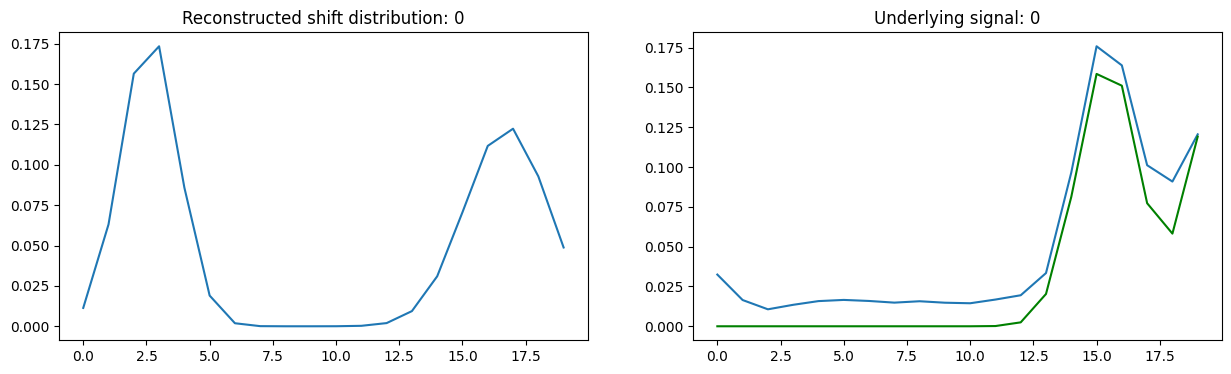

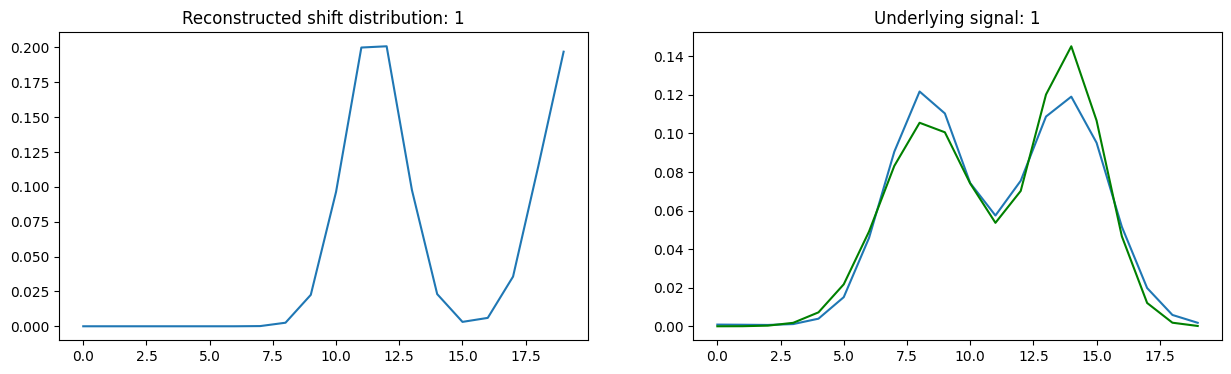

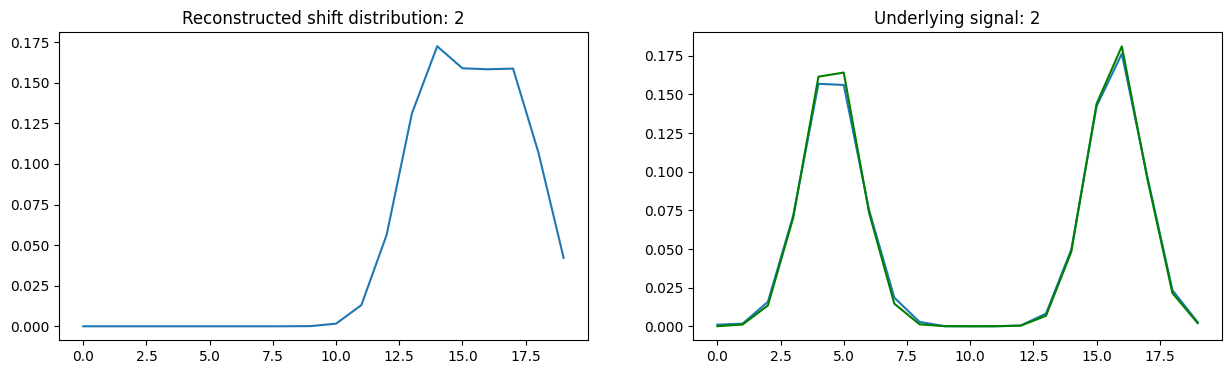

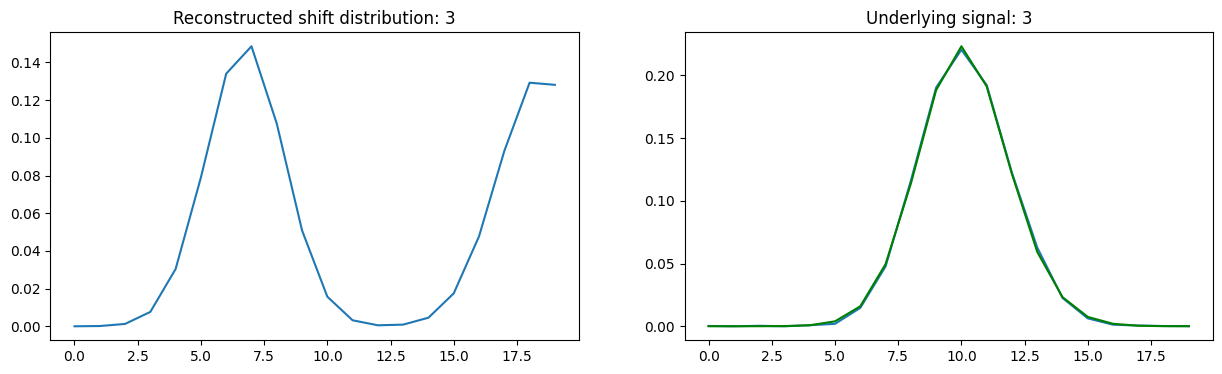

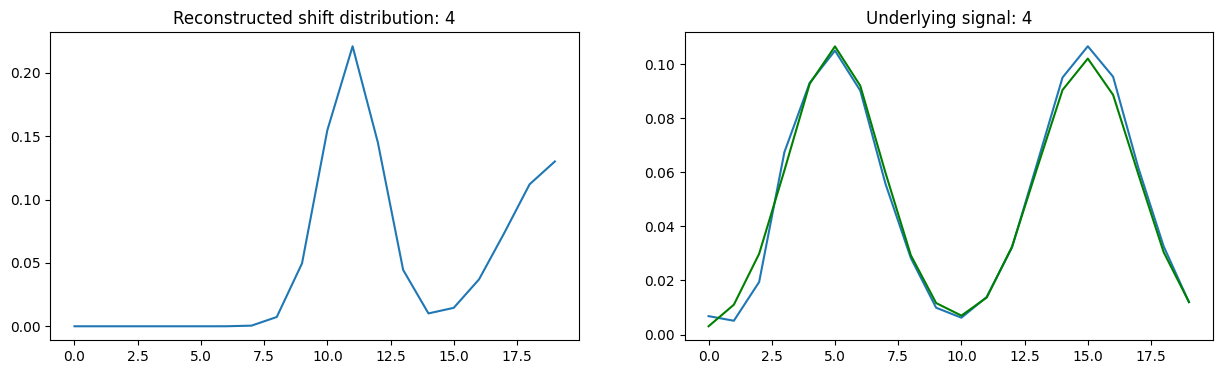

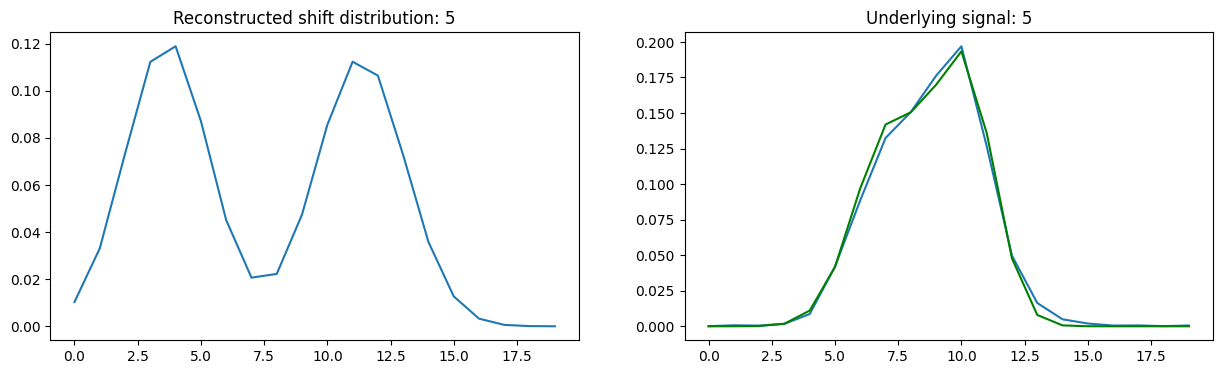

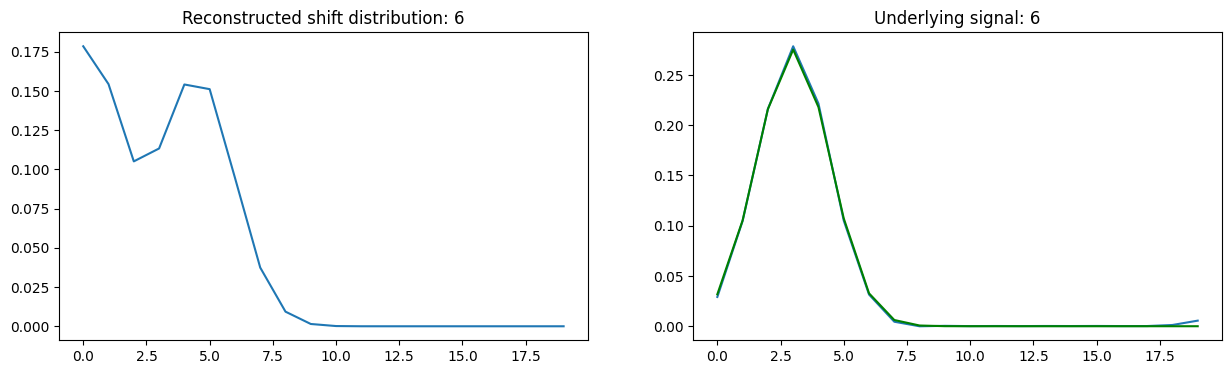

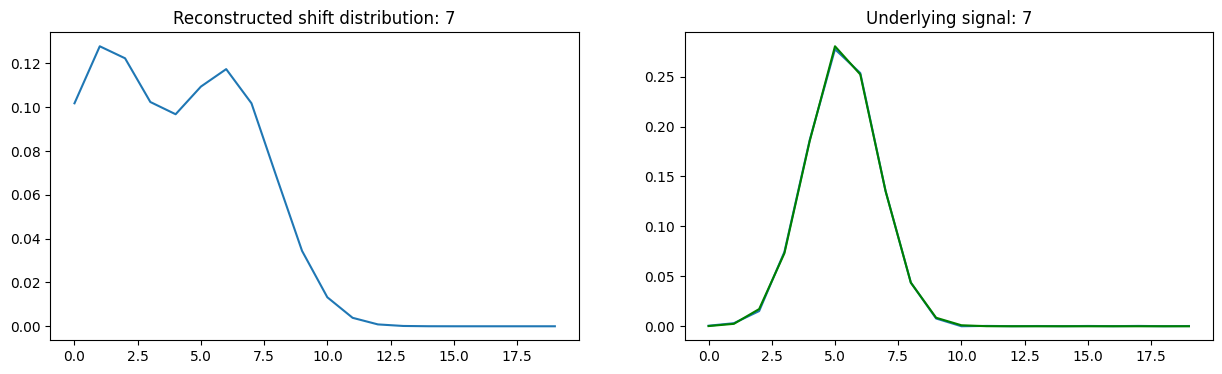

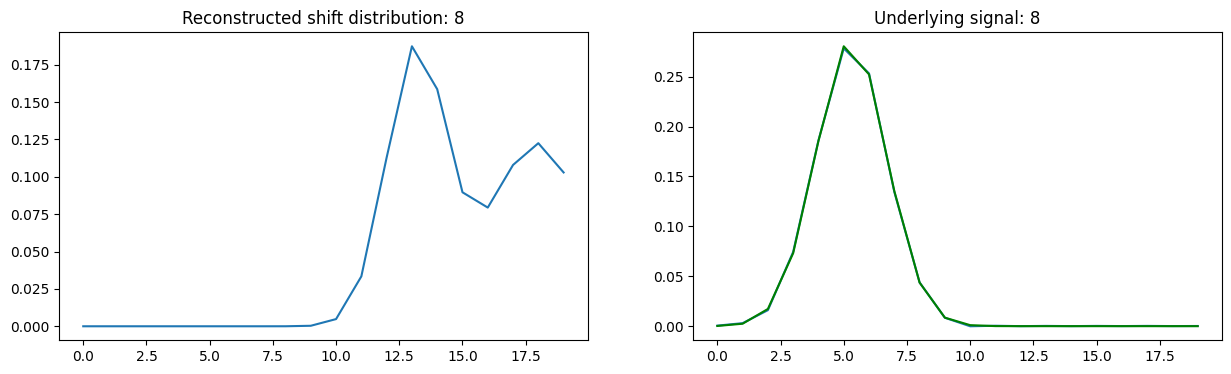

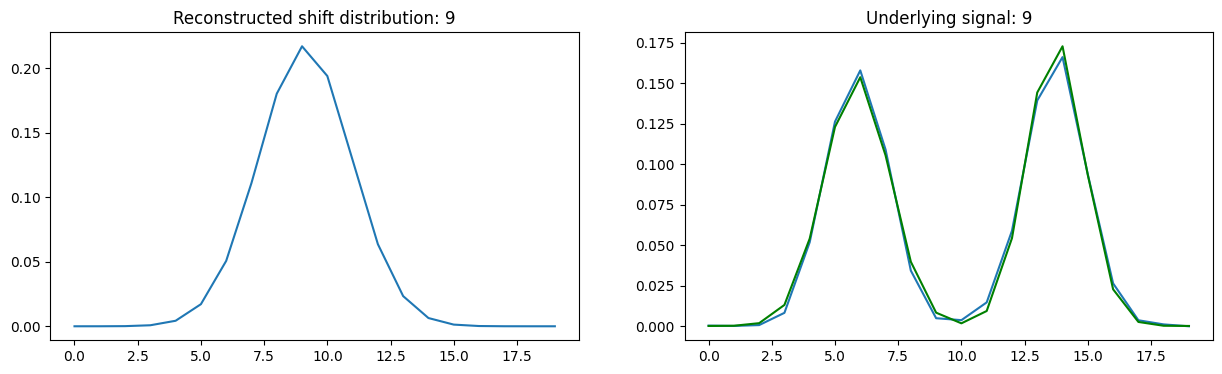

tensor(0.1655, grad_fn=<DivBackward0>)


In [ ]:
# Performance on training set
idxs = torch.randint(num_train, (10,))
i = 0
recon_v = model_v(m1_stack[idxs], m2_stack[idxs])

for idx in idxs:
    fig = plt.gcf()
    fig.set_size_inches(15, 4)

    best_s, best_error, best_recon = best_registration(sig_stack[idx], recon_v[i])

    plt.subplot(1, 2, 1)
    plt.plot(rho_stack[idx].cpu().numpy())
    plt.title(f'Reconstructed shift distribution: {i}')

    plt.subplot(1, 2, 2)
    plt.plot(best_recon.data.cpu().numpy())
    plt.plot(sig_stack[idx].cpu().numpy(), color='green')
    plt.title(f'Underlying signal: {i}')

    plt.show()
    i += 1

# print(idxs)
indices = torch.randint(num_train, (5000,)) # 1750000 + torch.randint(250000, (1000,)) #

fft_sig_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(sig_stack[indices])))
trans_sig_stack = rot_mat @ torch.diag_embed(fft_sig_stack)

recon_v = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_v(m1_stack[indices], m2_stack[indices]))))
loss = diff_min(torch.norm(recon_v[:, None, :] - trans_sig_stack, dim=2)).sum()/5000

print(loss)

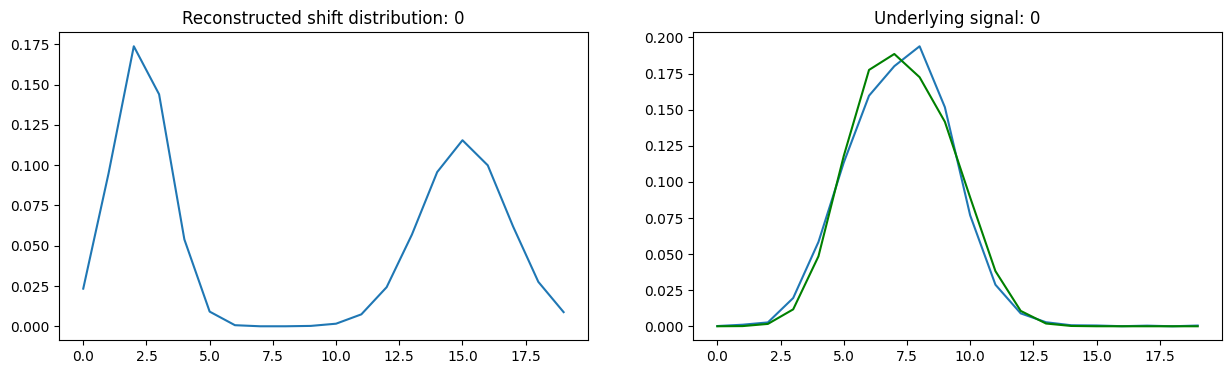

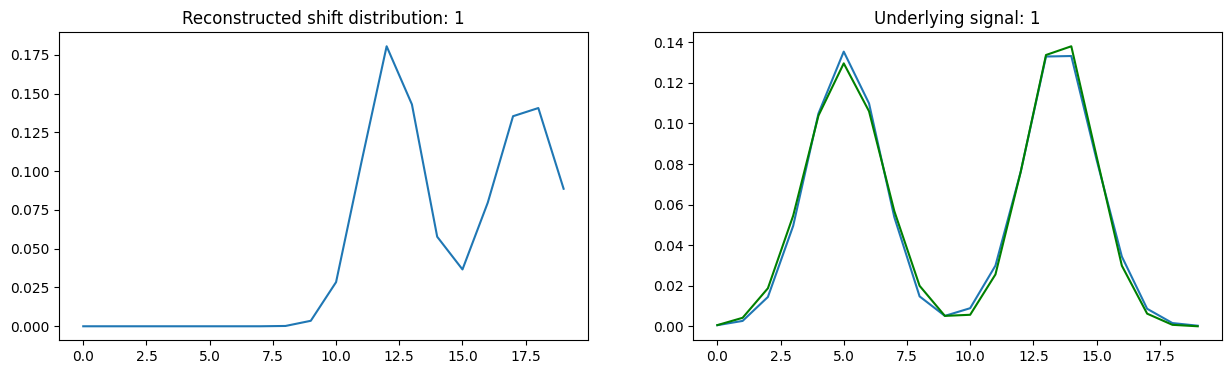

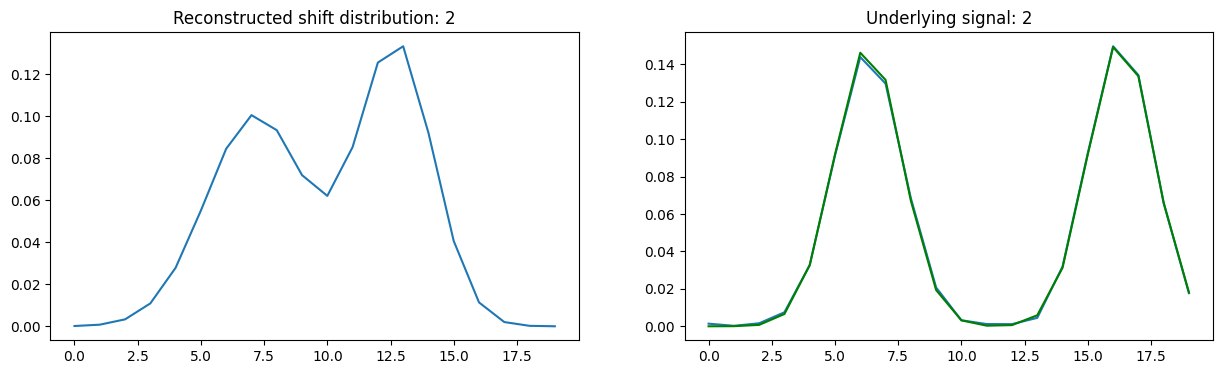

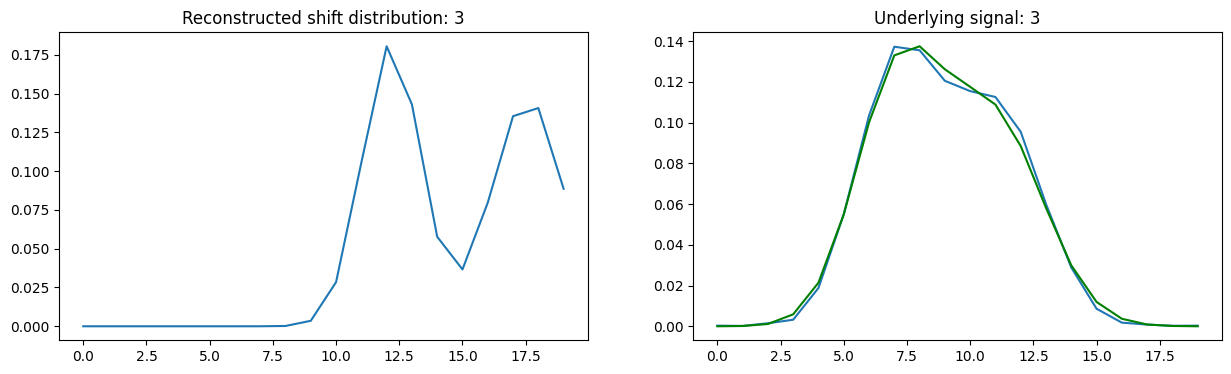

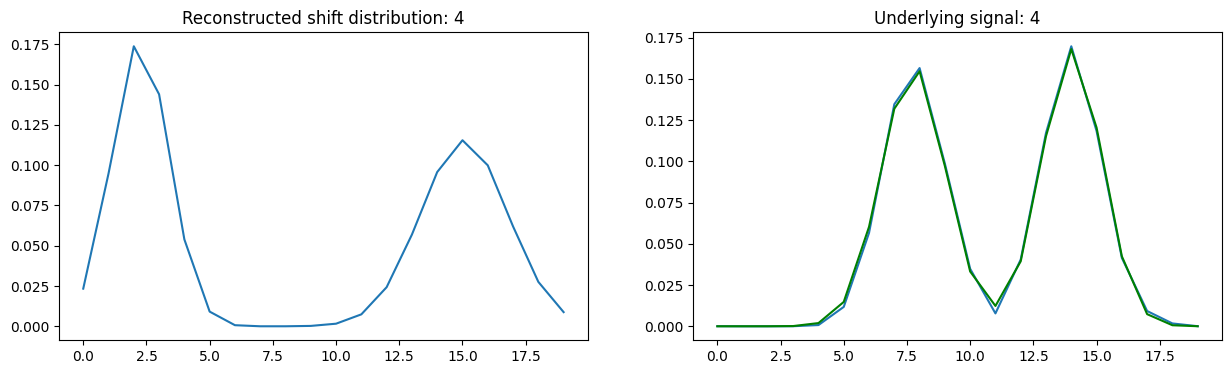

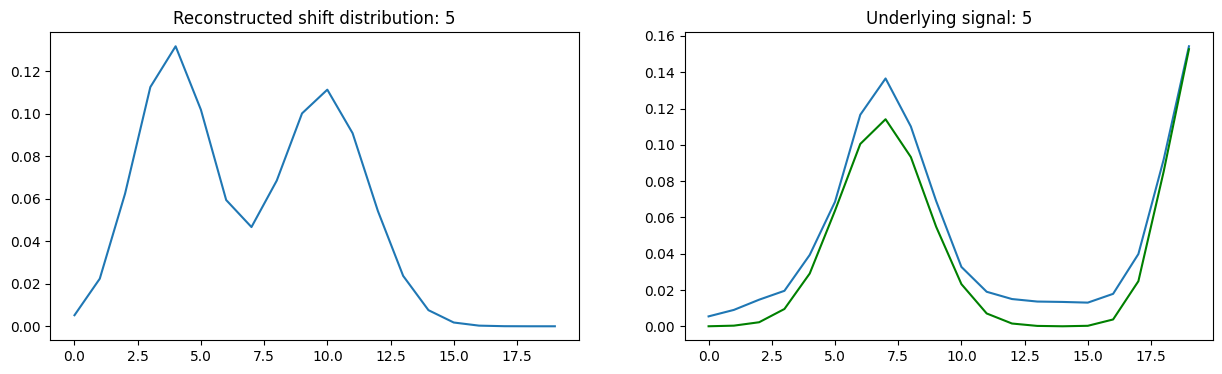

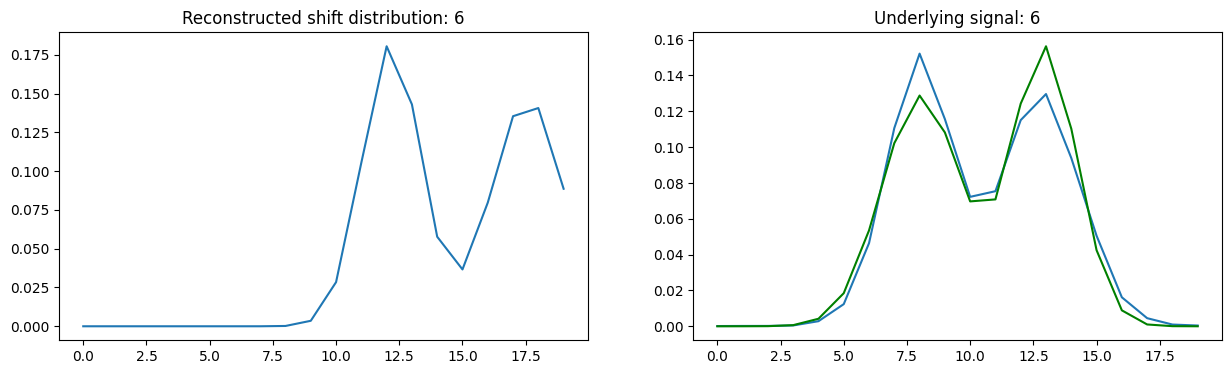

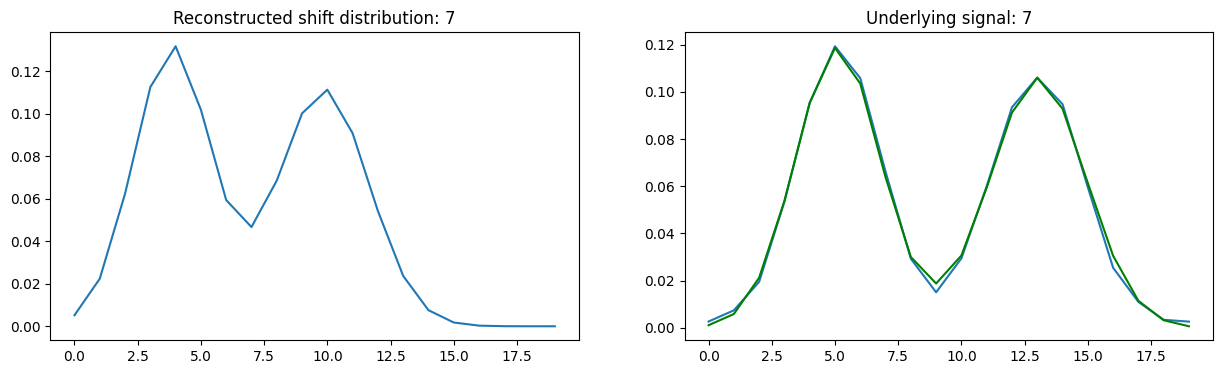

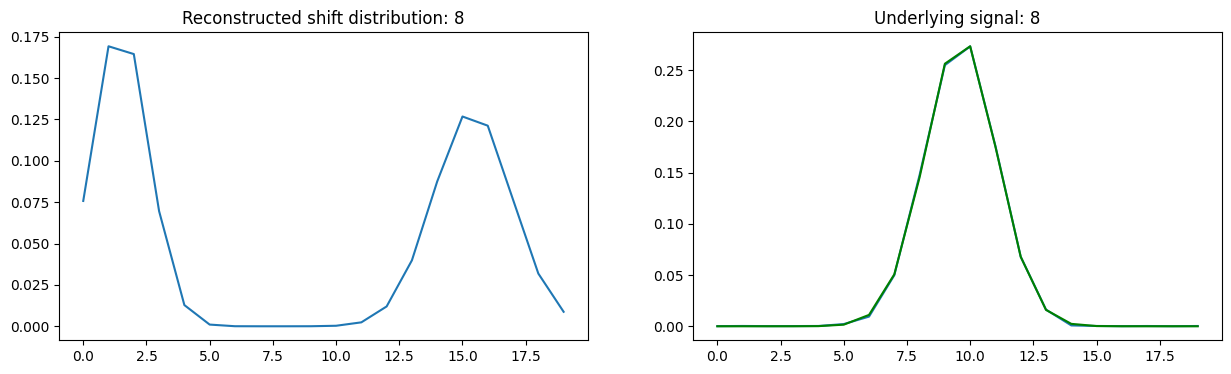

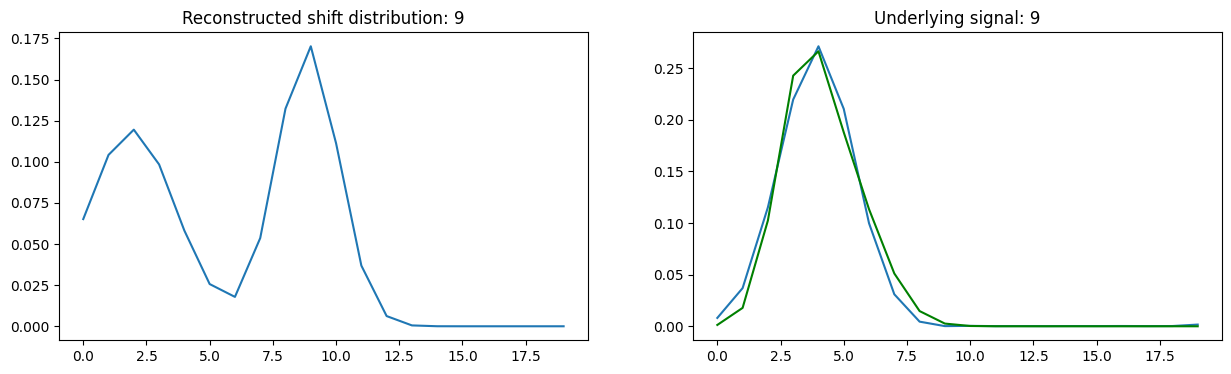

tensor(0.1644, grad_fn=<DivBackward0>)


In [ ]:
# num_train = len(m2_stack) - num_unique**2
# num_test = num_unique**2
s_list = torch.linspace(0, L-1, steps = 10*L, device=device)
rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()

# Performance on test set
idxs = num_train + torch.randint(num_test, (10,))
i = 0
recon_v = model_v(m1_stack[idxs], m2_stack[idxs])

for idx in idxs:
    fig = plt.gcf()
    fig.set_size_inches(15, 4)

    best_s, best_error, best_recon = best_registration(sig_stack[idx], recon_v[i])

    plt.subplot(1, 2, 1)
    plt.plot(rho_stack[idx].cpu().numpy())
    plt.title(f'Reconstructed shift distribution: {i}')

    plt.subplot(1, 2, 2)
    plt.plot(best_recon.data.cpu().numpy())
    plt.plot(sig_stack[idx].cpu().numpy(), color='green')
    plt.title(f'Underlying signal: {i}')

    plt.show()
    i += 1

indices = num_train + torch.randint(num_test, (5000,))

fft_sig_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(sig_stack[indices])))
trans_sig_stack = rot_mat @ torch.diag_embed(fft_sig_stack)

recon_v = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_v(m1_stack[indices], m2_stack[indices]))))
loss = diff_min(torch.norm(recon_v[:, None, :] - trans_sig_stack, dim=2)).sum()/5000

print(loss)

# Save datasets and models

In [ ]:
torch.save(rhos, 'rhos.pt')
torch.save(sigs, 'sigs.pt')

In [ ]:
torch.save(model_rho.state_dict(), 'model_rho.pt')

In [ ]:
model_rho = rhonet(act_parm=0.02).to(device)
model_rho.load_state_dict(torch.load('model_rho.pt'))

<All keys matched successfully>

In [ ]:
torch.save(model_v.state_dict(), 'model_v.pt')

In [ ]:
model_v = rhonet(act_parm=0.02).to(device)
model_v.load_state_dict(torch.load('model_sig.pt'))

<All keys matched successfully>

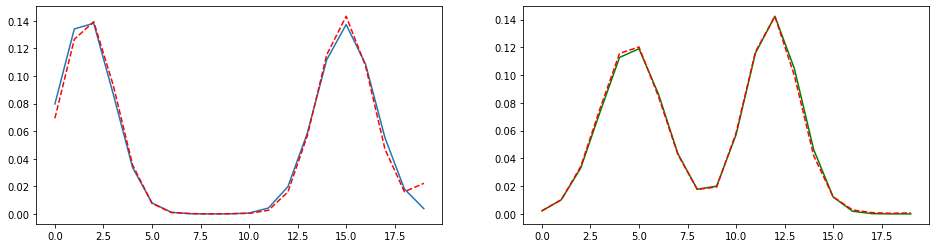

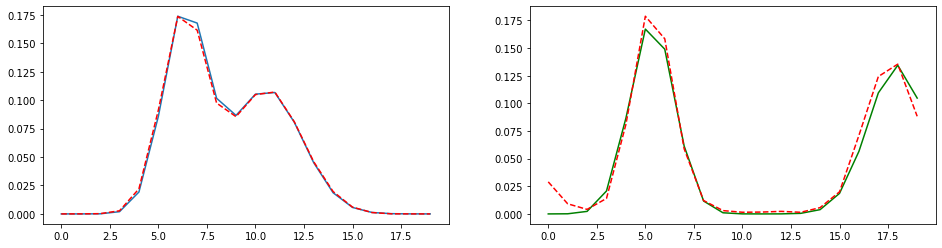

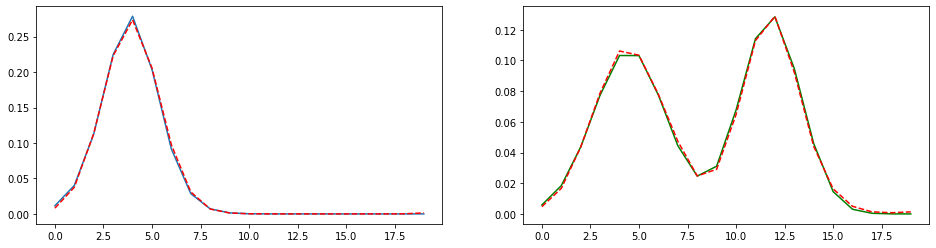

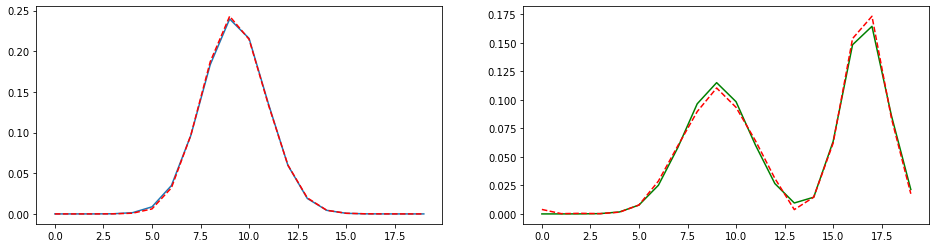

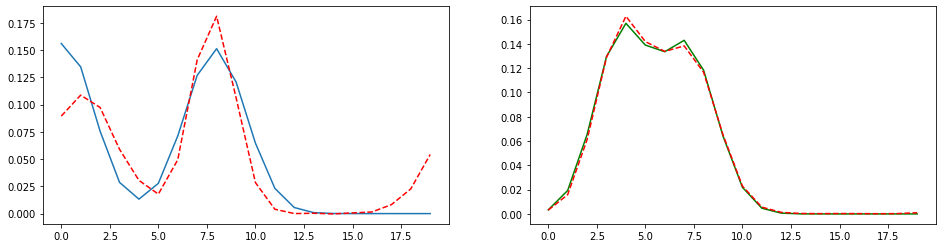

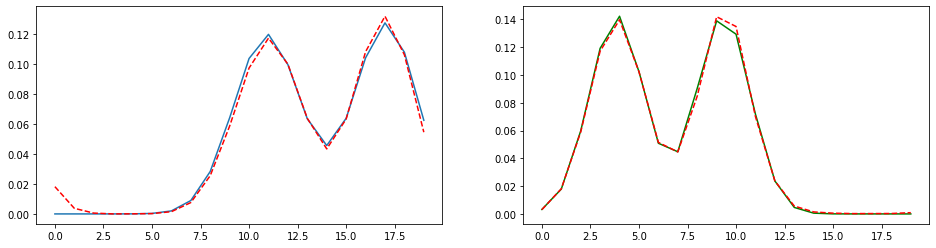

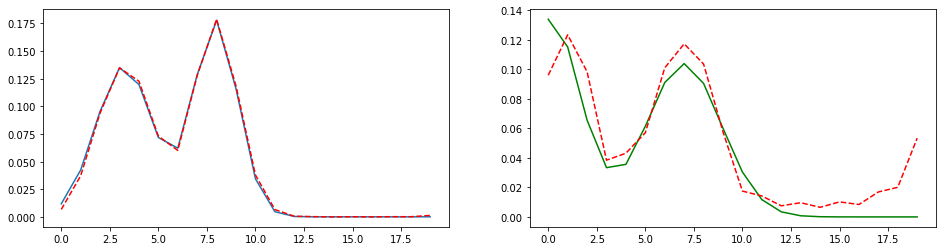

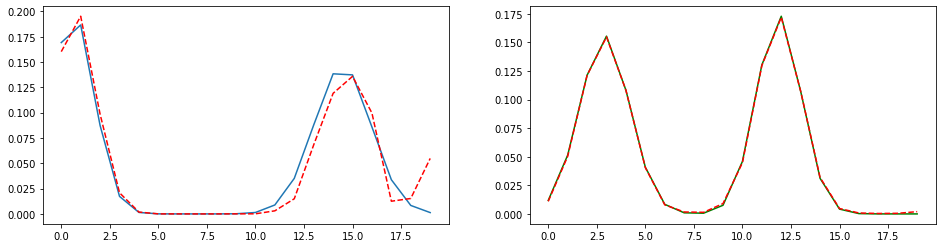

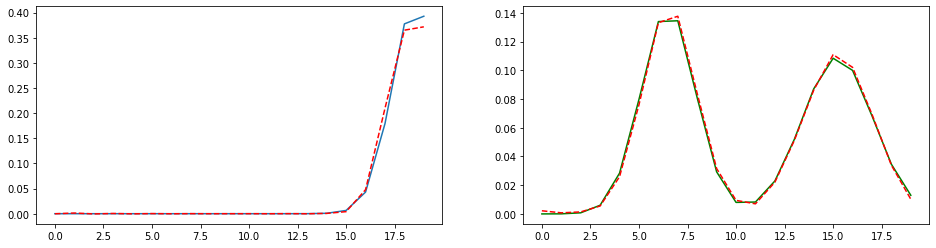

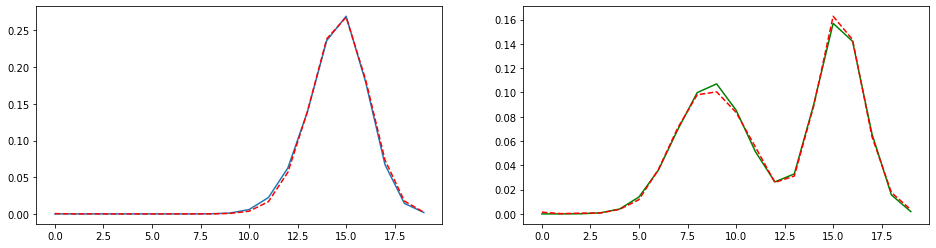

tensor(0.1533, device='cuda:0', grad_fn=<DivBackward0>)


In [ ]:
num_test = num_unique**2
num_train = len(m2_stack) - num_test
s_list = torch.linspace(0, L-1, steps = 10*L, device=device)
rot_mat = (s_list[:, None].type(torch.complex64) @ multiplier[None, :]).exp()

# Performance on test set
idxs = num_train + torch.randint(num_test, (10,))
i = 0
recon_v = model_v(m1_stack[idxs], m2_stack[idxs])
recon_rho = model_rho(m1_stack[idxs], m2_stack[idxs])

for idx in idxs:
    fig = plt.gcf()
    fig.set_size_inches(16, 4)

    # Registration of Rho
    best_s, best_error, best_recon = best_registration(rho_stack[idx], recon_rho[i])

    plt.subplot(1, 2, 1)
    plt.plot(rho_stack[idx].cpu().numpy())
    plt.plot(best_recon.data.cpu().numpy(), 'r--')
    # plt.title(f'Reconstructed shift distribution: {i}')

    # Registration of Signal
    best_s, best_error, best_recon = best_registration(sig_stack[idx], recon_v[i])

    plt.subplot(1, 2, 2)
    plt.plot(sig_stack[idx].cpu().numpy(), 'g')  #, color='green'
    plt.plot(best_recon.data.cpu().numpy(), 'r--')
    # plt.title(f'Underlying signal: {i}')

    plt.show()
    i += 1

    fig.savefig(f'learnt_rho_sig_{i}.svg', format='svg', dpi=1000)
    fig.savefig(f'learnt_rho_sig_{i}.png', format='png', dpi=1000)

indices = num_train + torch.randint(num_test, (5000,))

fft_sig_stack = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(sig_stack[indices])))
trans_sig_stack = rot_mat @ torch.diag_embed(fft_sig_stack)

recon_v = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(model_v(m1_stack[indices], m2_stack[indices]))))
loss = diff_min(torch.norm(recon_v[:, None, :] - trans_sig_stack, dim=2)).sum()/5000

print(loss)

# Final polishing

In [ ]:
case0_loss = np.load('case0_loss.npy')
case0_error = np.load('case0_error.npy')
case1_loss = np.load('case1_loss.npy', )
case1_error = np.load('case1_error.npy')

case0_loss25 = np.percentile(case0_loss, 25, axis=0)
case0_error25 = np.percentile(case0_error, 25, axis=0)
case1_loss25 = np.percentile(case1_loss, 25, axis=0)
case1_error25 = np.percentile(case1_error, 25, axis=0)

case0_loss75 = np.percentile(case0_loss, 75, axis=0)
case0_error75 = np.percentile(case0_error, 75, axis=0)
case1_loss75 = np.percentile(case1_loss, 75, axis=0)
case1_error75 = np.percentile(case1_error, 75, axis=0)

# Task
Refactor the provided notebook into multiple Python files and one main notebook file, ensuring that the variables `L`, `s`, `noise_sdmult`, and `num_samps` are shared across all files.

## Create a configuration file

### Subtask:
Create a new Python file (e.g., `config.py`) to store the shared variables `L`, `s`, `noise_sdmult`, and `num_samps`.


**Reasoning**:
The subtask is to create a Python file `config.py` and store the shared variables within it. This can be done by writing the variable assignments directly into the file.



## Refactor code into modules

### Subtask:
Move related functions and classes from the notebook into separate Python files (e.g., `utils.py` for helper functions, `models.py` for neural network definitions). Import the necessary variables from `config.py` into these files.


**Reasoning**:
Create the `utils.py` file and move the specified functions into it, importing necessary libraries and variables from `config.py`.



**Reasoning**:
The previous attempt to create `utils.py` failed because `config.py` was not yet created in the current environment. Create `config.py` first, then create `utils.py` with the necessary functions and imports.



**Reasoning**:
Now that `config.py` is created, create the `utils.py` file and move the specified functions into it, importing necessary libraries and variables from `config.py`.



**Reasoning**:
Create the `models.py` file and move the specified class definitions into it, importing necessary libraries and the variable `L` from `config.py`.



## Update the notebook

### Subtask:
Modify the notebook to import functions, classes, and shared variables from the newly created Python files (`config.py`, `utils.py`, and `models.py`).


**Reasoning**:
Modify the notebook to import shared variables, helper functions, and neural network classes from the refactored Python files and remove their original definitions.



**Reasoning**:
The import of `multiplier` from `utils` failed because `multiplier` was defined inside a function in `utils.py`. Move the definition of `multiplier` outside the function in `utils.py` to make it importable.



**Reasoning**:
Retry the previous code block to import the necessary components from the refactored files after fixing the `ImportError`.



**Reasoning**:
The previous attempt to import `multiplier` failed again, indicating the change to `utils.py` was not applied. Re-apply the change to `utils.py` to move the `multiplier` definition outside the function.



**Reasoning**:
Retry the previous code block to import the necessary components from the refactored files after fixing the `ImportError` in `utils.py`.



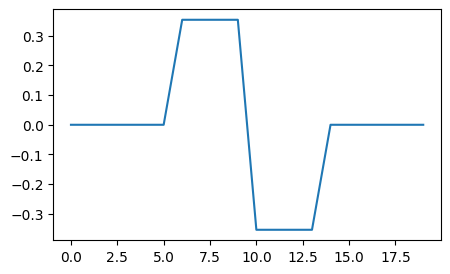

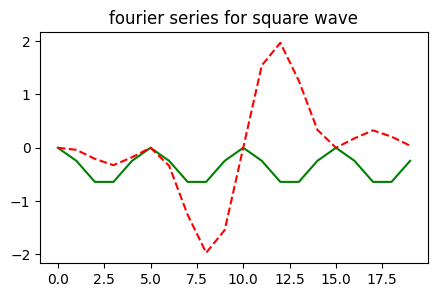

In [ ]:
# Import basic libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# For plotting
import matplotlib.pyplot as plt
from tqdm import tqdm

# For saving and loading
import pickle
%matplotlib inline

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')

plt.rcParams['figure.figsize'] = [5, 3]

# Import shared variables from config.py
from config.config import L, s, noise_sdmult, num_samps

# Import helper functions from utils.py
from utils import circ, mix_gauss, circular_trans_fourier, circular_trans, diff_min, create_moments, create_data, best_registration, moment_registration, multiplier

# Import neural network classes from models.py
from models import rhonet, signet

signal = torch.cat((torch.zeros(6, device=device), torch.ones(4, device=device), -torch.ones(4, device=device), torch.zeros(6, device=device)), 0)
# signal = mix_gauss(torch.linspace(0, 1, steps=L)).to(device)  #, amp=torch.tensor([1.]), mu=torch.tensor([1/2]), sd=torch.tensor([1/3])
#signal = torch.rand(L)
signal *= 1/torch.norm(signal)
fft_signal = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(signal)))

# Plot signal in both real and fourier domain
plt.plot(signal.cpu())
plt.show()

plt.plot(fft_signal.cpu().real, 'g')
plt.plot(fft_signal.cpu().imag,'r--')
plt.title("fourier series for square wave")

plt.show()

# Task
Refactor the notebook to use separate Python files for functions and shared variables, allowing the user to define the shared variables.

## Create a configuration file with user input

### Subtask:
Create a new Python file (e.g., `config.py`) to store the shared variables `L`, `s`, `noise_sdmult`, and `num_samps`, and includes code to allow the user to set these values, perhaps through command-line arguments or by reading from a configuration file.


**Reasoning**:
The subtask is to create a `config.py` file with shared variables and the ability for users to set their values. This requires writing the code to define and potentially parse configuration options within this new file.

